In [4]:
import pandas as pd

df_if = pd.read_parquet("../data/processed/dimuon_anomaly_results.parquet")


df_ae = pd.read_parquet("../data/processed/dimuon_anomaly_autoencoder.parquet")


df = df_if.merge(
    df_ae[["anomaly_score_autoencoder", "anomaly_label_autoencoder"]],
    left_index=True,
    right_index=True
)

df.head()


,pt1,eta1,phi1,E1,Q1,pt2,eta2,phi2,E2,Q2,M,anomaly_score,anomaly_label,anomaly_score_autoencoder,anomaly_label_autoencoder
0,4.2116,2.2366,-0.4849,19.9382,1,1.2556,2.2683,-1.4488,6.1319,-1,2.1330,0.168426,1,0.012102,1
1,2.1479,-2.0159,-2.7753,8.2066,-1,19.5453,-1.0826,-0.3408,32.1613,1,13.6786,0.108845,1,0.125948,1
2,21.0732,1.5948,-1.1137,54.0560,1,2.3864,1.5352,-1.7388,5.7968,-1,4.3813,0.170665,1,0.067624,1
3,18.5889,1.6422,1.1923,49.8180,1,1.8721,1.9704,1.6393,6.8459,-1,3.2587,0.165416,1,0.038473,1
4,11.8194,0.8711,-1.5811,16.5947,-1,0.9408,2.0107,-1.6559,3.5779,1,4.0171,0.171313,1,0.025798,1


In [6]:
df["ensemble_strong"] = ((df["anomaly_label"] == -1) &
                         (df["anomaly_label_autoencoder"] == -1)).astype(int)

df["ensemble_if_only"] = ((df["anomaly_label"] == -1) &
                          (df["anomaly_label_autoencoder"] == 1)).astype(int)

df["ensemble_ae_only"] = ((df["anomaly_label"] == 1) &
                           (df["anomaly_label_autoencoder"] == -1)).astype(int)

df["ensemble_none"] = ((df["anomaly_label"] == 1) &
                       (df["anomaly_label_autoencoder"] == 1)).astype(int)

from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
df["if_norm"] = sc.fit_transform(df[["anomaly_score"]])
df["ae_norm"] = sc.fit_transform(df[["anomaly_score_autoencoder"]])

df["combined_score"] = 0.5 * df["if_norm"] + 0.5 * df["ae_norm"]

df.head()


,pt1,eta1,phi1,E1,Q1,pt2,eta2,phi2,E2,Q2,...,anomaly_label,anomaly_score_autoencoder,anomaly_label_autoencoder,ensemble_strong,ensemble_if_only,ensemble_ae_only,ensemble_none,if_norm,ae_norm,combined_score
0,4.2116,2.2366,-0.4849,19.9382,1,1.2556,2.2683,-1.4488,6.1319,-1,...,1,0.012102,1,0,0,0,1,0.927118,0.000009,0.463564
1,2.1479,-2.0159,-2.7753,8.2066,-1,19.5453,-1.0826,-0.3408,32.1613,1,...,1,0.125948,1,0,0,0,1,0.736129,0.000096,0.368112
2,21.0732,1.5948,-1.1137,54.0560,1,2.3864,1.5352,-1.7388,5.7968,-1,...,1,0.067624,1,0,0,0,1,0.934293,0.000051,0.467172
3,18.5889,1.6422,1.1923,49.8180,1,1.8721,1.9704,1.6393,6.8459,-1,...,1,0.038473,1,0,0,0,1,0.917469,0.000029,0.458749
4,11.8194,0.8711,-1.5811,16.5947,-1,0.9408,2.0107,-1.6559,3.5779,1,...,1,0.025798,1,0,0,0,1,0.936373,0.000019,0.468196


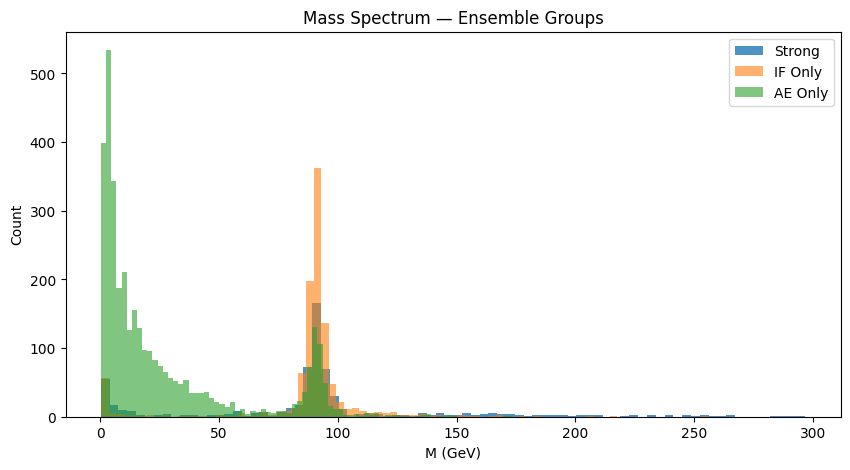

In [7]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df[df["ensemble_strong"]==1]["M"], bins=80, alpha=0.8, label="Strong")
plt.hist(df[df["ensemble_if_only"]==1]["M"], bins=80, alpha=0.6, label="IF Only")
plt.hist(df[df["ensemble_ae_only"]==1]["M"], bins=80, alpha=0.6, label="AE Only")
plt.legend()
plt.title("Mass Spectrum — Ensemble Groups")
plt.xlabel("M (GeV)")
plt.ylabel("Count")
plt.show()

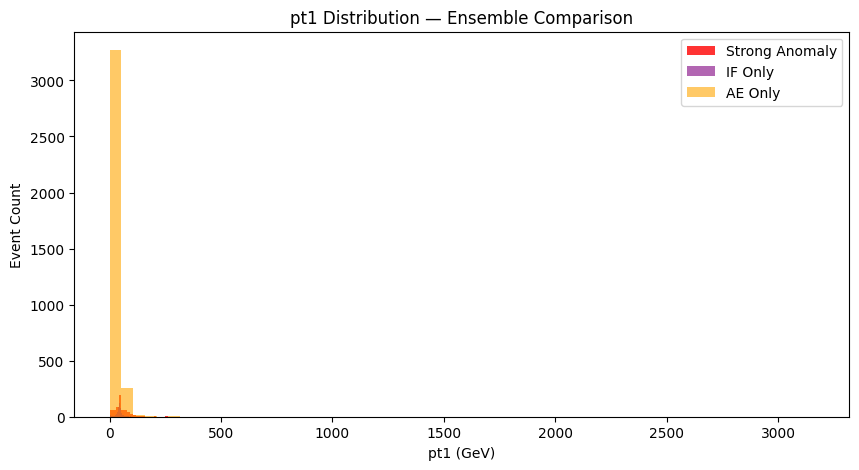

In [8]:
plt.figure(figsize=(10,5))

plt.hist(df[df["ensemble_strong"] == 1]["pt1"],
         bins=60, alpha=0.8, label="Strong Anomaly", color="red")

plt.hist(df[df["ensemble_if_only"] == 1]["pt1"],
         bins=60, alpha=0.6, label="IF Only", color="purple")

plt.hist(df[df["ensemble_ae_only"] == 1]["pt1"],
         bins=60, alpha=0.6, label="AE Only", color="orange")

plt.xlabel("pt1 (GeV)")
plt.ylabel("Event Count")
plt.title("pt1 Distribution — Ensemble Comparison")
plt.legend()
plt.show()

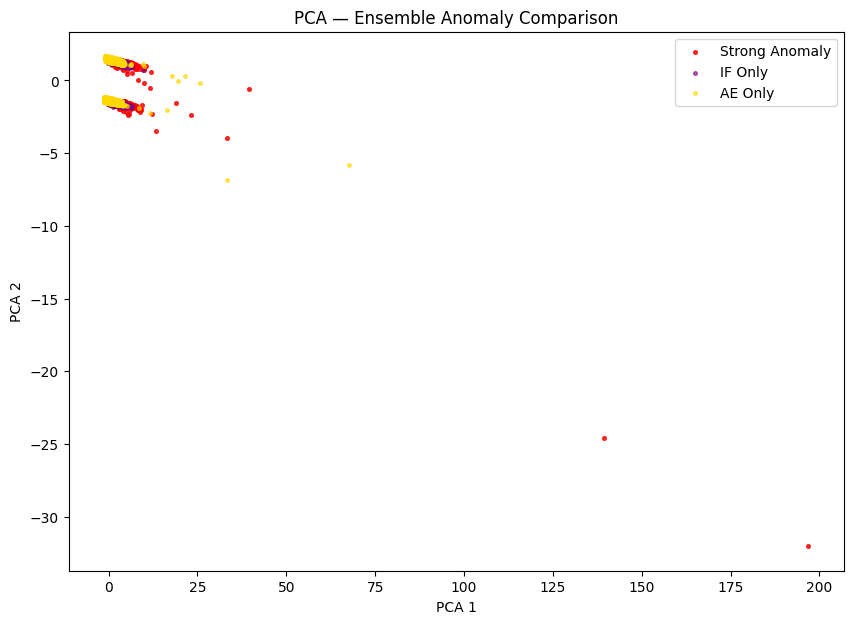

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

numeric_cols = ["pt1","eta1","phi1","E1","Q1",
                "pt2","eta2","phi2","E2","Q2","M"]

X = df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["pca1"] = pca_result[:,0]
df["pca2"] = pca_result[:,1]


df["ensemble_strong"] = df["ensemble_strong"].astype(bool)
df["ensemble_if_only"] = df["ensemble_if_only"].astype(bool)
df["ensemble_ae_only"] = df["ensemble_ae_only"].astype(bool)
# ----------------------------

plt.figure(figsize=(10,7))

plt.scatter(
    df.loc[df["ensemble_strong"], "pca1"],
    df.loc[df["ensemble_strong"], "pca2"],
    s=7, color="red", alpha=0.8, label="Strong Anomaly"
)

plt.scatter(
    df.loc[df["ensemble_if_only"], "pca1"],
    df.loc[df["ensemble_if_only"], "pca2"],
    s=7, color="purple", alpha=0.6, label="IF Only"
)

plt.scatter(
    df.loc[df["ensemble_ae_only"], "pca1"],
    df.loc[df["ensemble_ae_only"], "pca2"],
    s=7, color="gold", alpha=0.6, label="AE Only"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA — Ensemble Anomaly Comparison")
plt.legend()
plt.show()
